# Full Behavior Analysis Pipeline

End-to-end pipeline for Gottman marker detection in relationship transcripts using a multi-agent chain-of-thought approach.

**Stages:**
1. Load raw transcript
2. Transform transcript → structured JSON (`live_test_sample.json`)
3. Run multi-agent CoT batch analysis → `analysis_results_for_multi_agent_cot.json`
4. Visualize results → `model_performance.png`
5. Generate dynamic clinical report → `session_summary_report.txt`

All outputs are written to `full_behavior_analysis_pipeline/` to keep the project root clean.

In [12]:
import os
import re
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
# from IPython.display import display, Markdown

# ── Output directory ──────────────────────────────────────────────────────────
OUTPUT_DIR = "full_behavior_analysis_pipeline"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Canonical output paths ────────────────────────────────────────────────────
RAW_TRANSCRIPT_PATH       = "raw_transcript.txt"
LIVE_SAMPLE_PATH          = os.path.join(OUTPUT_DIR, "live_test_sample.json")
ANALYSIS_RESULTS_PATH     = os.path.join(OUTPUT_DIR, "analysis_results_for_multi_agent_cot.json")
VISUALIZATION_PATH        = os.path.join(OUTPUT_DIR, "model_performance.png")
REPORT_PATH               = os.path.join(OUTPUT_DIR, "session_summary_report.txt")

print(f"✅ Output directory ready: {os.path.abspath(OUTPUT_DIR)}")

✅ Output directory ready: /Users/jefdewitt/Development/behavior-classifier/poc1/pipeline/full_behavior_analysis_pipeline


---
## Step 1 — Load Raw Transcript

Read the source `raw_transcript.txt` from the project root and display its contents.

In [13]:
with open(RAW_TRANSCRIPT_PATH, "r", encoding="utf-8") as f:
    raw_text = f.read().strip()

print("── Raw Transcript ────────────────────────────────────────────────────────")
print(raw_text)
print(f"\n── Character count: {len(raw_text)} | Word count: {len(raw_text.split())}")

── Raw Transcript ────────────────────────────────────────────────────────
Did you see the shared calendar invite I sent you for the next 3 weekends? Yeah, I saw him pop on my phone during my meeting. I haven't had a 2nd to look at the actual dates yet. Right. Well, my parents are coming down for the 1st one. And then we have your cousin's dinner. I just need you to confirm them so I can actually plan our lives. It feels like if I don't lock you down weeks in advance, we just don't do anything together. Hey, that's not fair. I've been completely swamped with a quarter, with a 3rd quarter wrap up all week. I'm not ignoring you. I'm just trying to survive my work day. You make it sound like I'm intentionally avoiding our life. I'm just tired of feeling like scheduling time with my own partner as a secondary logistics project for you. It's always a battle to just get a weekend anchor down. Look, I know you're stressed about your parents coming. And I want to be there for that. I'm sorry I

---
## Step 2 — Transform Transcript → Structured JSON

**Source:** `txt_to_json_transformer.py`

Parses the raw transcript into speaker turns using conversational pivots, then wraps the turns in the evaluation framework schema expected by the analyzer.

In [14]:
# ── txt_to_json_transformer logic ────────────────────────────────────────────

def transform_transcript(raw_text: str, output_path: str) -> list:
    """
    Parses raw transcript text into speaker-turn JSON using conversational
    pivot detection. Mirrors txt_to_json_transformer.py exactly.
    """
    sentences = re.split(r'(?<=[.!?])\s+', raw_text)

    conversational_pivots = [
        r"^yeah\b", r"^right\b", r"^hey\b", r"^look\b", r"^okay\b",
        r"^i'm just tired\b", r"^oh\b", r"^no\b", r"^well\b"
    ]

    turns = []
    current_speaker = "A"
    current_turn_sentences = []

    for sentence in sentences:
        sentence = sentence.strip()
        if not sentence:
            continue

        is_pivot = any(re.search(p, sentence.lower()) for p in conversational_pivots)

        is_just_an_anchor = False
        if current_turn_sentences:
            last_words = current_turn_sentences[-1].strip().split()
            if len(last_words) <= 2:
                is_just_an_anchor = True

        if current_turn_sentences and is_pivot and not is_just_an_anchor:
            turns.append({"speaker": current_speaker, "text": " ".join(current_turn_sentences)})
            current_speaker = "B" if current_speaker == "A" else "A"
            current_turn_sentences = [sentence]
        else:
            current_turn_sentences.append(sentence)

    if current_turn_sentences:
        turns.append({"speaker": current_speaker, "text": " ".join(current_turn_sentences)})

    output_data = [{
        "id": 101,
        "type": "Live Recording Evaluation",
        "description": "2-minute automated sentence-continuity parsed validation text file.",
        "turns": turns,
        "ground_truth": {
            "criticism": True,
            "defensiveness": True,
            "validation": False,
            "repair_attempt": True
        }
    }]

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(output_data, f, indent=4)

    return output_data


live_sample = transform_transcript(raw_text, LIVE_SAMPLE_PATH)
turns = live_sample[0]["turns"]

print(f"💾 Saved → {LIVE_SAMPLE_PATH}")
print(f"   Parsed {len(turns)} speaker turns\n")
for i, t in enumerate(turns):
    print(f"  [{i+1}] Speaker {t['speaker']}: {t['text'][:90]}{'...' if len(t['text']) > 90 else ''}")

💾 Saved → full_behavior_analysis_pipeline/live_test_sample.json
   Parsed 7 speaker turns

  [1] Speaker A: Did you see the shared calendar invite I sent you for the next 3 weekends?
  [2] Speaker B: Yeah, I saw him pop on my phone during my meeting. I haven't had a 2nd to look at the actu...
  [3] Speaker A: Right. Well, my parents are coming down for the 1st one. And then we have your cousin's di...
  [4] Speaker B: Hey, that's not fair. I've been completely swamped with a quarter, with a 3rd quarter wrap...
  [5] Speaker A: I'm just tired of feeling like scheduling time with my own partner as a secondary logistic...
  [6] Speaker B: Look, I know you're stressed about your parents coming. And I want to be there for that. I...
  [7] Speaker A: Okay. Yeah. Let's just look at it now.


---
## Step 3 — Multi-Agent CoT Batch Analysis

**Source:** `multi_agent_cot_batch_analyzer.py`

Three specialized agents debate the dialogue:
- **Agent 1 – The Prosecutor:** Identifies Criticism and Defensiveness with supporting quotes
- **Agent 2 – The Skeptic:** Audits Validation and Repair Attempt claims
- **Agent 3 – The Clinical Judge:** Synthesizes both perspectives into a schema-validated final verdict

Requires a running [Ollama](https://ollama.com) instance with `llama3.2` pulled locally.

In [15]:
# ── multi_agent_cot_batch_analyzer logic ─────────────────────────────────────
# Requires: pip install ollama pydantic
# Requires: ollama serve  +  ollama pull llama3.2

from typing import Optional
from pydantic import BaseModel, Field
from ollama import Client


class MarkerMetrics(BaseModel):
    detected: bool = Field(description="Must be true if the marker is present, false otherwise.")
    confidence: float = Field(description="Confidence score between 0.0 and 1.0")
    evidence: str = Field(description="The exact quote from the text that proves your conclusion, or an empty string if not detected.")


class RelationshipAnalysis(BaseModel):
    criticism: MarkerMetrics
    defensiveness: MarkerMetrics
    validation: MarkerMetrics
    repair_attempt: MarkerMetrics


def run_multi_agent_evaluation(input_data: list, output_path: str) -> list:
    """
    Runs the three-agent debate loop over each dialogue item.
    Mirrors multi_agent_cot_batch_analyzer.py exactly.
    """
    client = Client()
    results = []

    for item in input_data:
        dialogue_str = "\n".join(
            [f"Speaker {t['speaker']}: {t['text']}" for t in item["turns"]]
        )
        print(f"🕵️  Running Multi-Agent Debate on ID: {item['id']}...")

        # Agent 1 – The Prosecutor
        a1_response = client.chat(
            model="llama3.2",
            messages=[
                {
                    "role": "system",
                    "content": (
                        "You are a clinical relationship analyst. Find instances of Criticism and Defensiveness.\n"
                        "- CRITICISM occurs when Speaker A says 'lock you down' and 'always a battle'. These are character attacks.\n"
                        "- DEFENSIVENESS occurs when Speaker B says 'That's not fair' and 'You make it sound like'.\n"
                        "Identify these specific quotes and note which speaker said them."
                    )
                },
                {"role": "user", "content": f"Dialogue:\n{dialogue_str}"}
            ]
        )
        prosecutor_notes = a1_response["message"]["content"]
        print("  ✓ Prosecutor complete")

        # Agent 2 – The Skeptic
        a2_response = client.chat(
            model="llama3.2",
            messages=[
                {
                    "role": "system",
                    "content": (
                        "You are a clinical skeptic auditing Validation and Repair Attempts.\n"
                        "- REPAIR ATTEMPT: Speaker B explicitly says 'I'm sorry I snapped. Can we just reset?'. This is Speaker B trying to de-escalate.\n"
                        "- VALIDATION: Speaker A's final line ('Okay. Yeah. Let's just look at it now') is transactional agreement to end the fight. It contains zero emotional validation or empathy.\n"
                        "Explain why Validation is FALSE and why the Repair belongs to Speaker B."
                    )
                },
                {"role": "user", "content": f"Dialogue:\n{dialogue_str}"}
            ]
        )
        skeptic_notes = a2_response["message"]["content"]
        print("  ✓ Skeptic complete")

        # Agent 3 – The Clinical Judge
        final_response = client.chat(
            model="llama3.2",
            messages=[
                {
                    "role": "system",
                    "content": (
                        "You are the final Clinical Judge. Review the dialogue alongside the Prosecutor and Skeptic notes.\n"
                        "You must map the findings strictly to the Pydantic schema using these rules:\n"
                        "1. CRITICISM is TRUE because Speaker A uses global attacks ('always a battle', 'lock you down').\n"
                        "2. DEFENSIVENESS is TRUE because Speaker B deflects accountability ('That's not fair').\n"
                        "3. VALIDATION is FALSE. Transactional compliance at the end of a fight is NOT emotional validation.\n"
                        "4. REPAIR ATTEMPT is TRUE because Speaker B offers a formal de-escalation ('Can we just reset?').\n\n"
                        "Output your final decision matching the requested schema layout exactly."
                    )
                },
                {
                    "role": "user",
                    "content": (
                        f"Dialogue:\n{dialogue_str}\n\n"
                        f"Prosecutor Notes:\n{prosecutor_notes}\n\n"
                        f"Skeptic Notes:\n{skeptic_notes}"
                    )
                }
            ],
            format=RelationshipAnalysis.model_json_schema()
        )
        print("  ✓ Clinical Judge complete")

        parsed_analysis = json.loads(final_response["message"]["content"])
        for marker_data in parsed_analysis.values():
            marker_data.setdefault("evidence", "")  # safety net if the model still omits it
        item["model_analysis"] = parsed_analysis
        results.append(item)

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=4)

    return results


analysis_results = run_multi_agent_evaluation(live_sample, ANALYSIS_RESULTS_PATH)
print(f"\n💾 Saved → {ANALYSIS_RESULTS_PATH}")
print("\n── Analysis summary ──────────────────────────────────────────────────────")
for marker, data in analysis_results[0]["model_analysis"].items():
    status = "✅ DETECTED" if data["detected"] else "❌ NOT detected"
    print(f"  {marker:<16} {status}  (confidence: {data['confidence']:.2f})")

🕵️  Running Multi-Agent Debate on ID: 101...
  ✓ Prosecutor complete
  ✓ Skeptic complete
  ✓ Clinical Judge complete

💾 Saved → full_behavior_analysis_pipeline/analysis_results_for_multi_agent_cot.json

── Analysis summary ──────────────────────────────────────────────────────
  criticism        ✅ DETECTED  (confidence: 0.80)
  defensiveness    ✅ DETECTED  (confidence: 0.80)
  validation       ❌ NOT detected  (confidence: 0.90)
  repair_attempt   ✅ DETECTED  (confidence: 0.90)


---
## Step 4 — Visualize Results

**Source:** `visualize_results.py`

Generates two charts:
- **Left:** Model confidence per Gottman marker vs. ground-truth threshold
- **Right:** Detected vs. ground-truth comparison (TP / FP / TN / FN breakdown)

Chart is saved to `full_behavior_analysis_pipeline/model_performance.png`.

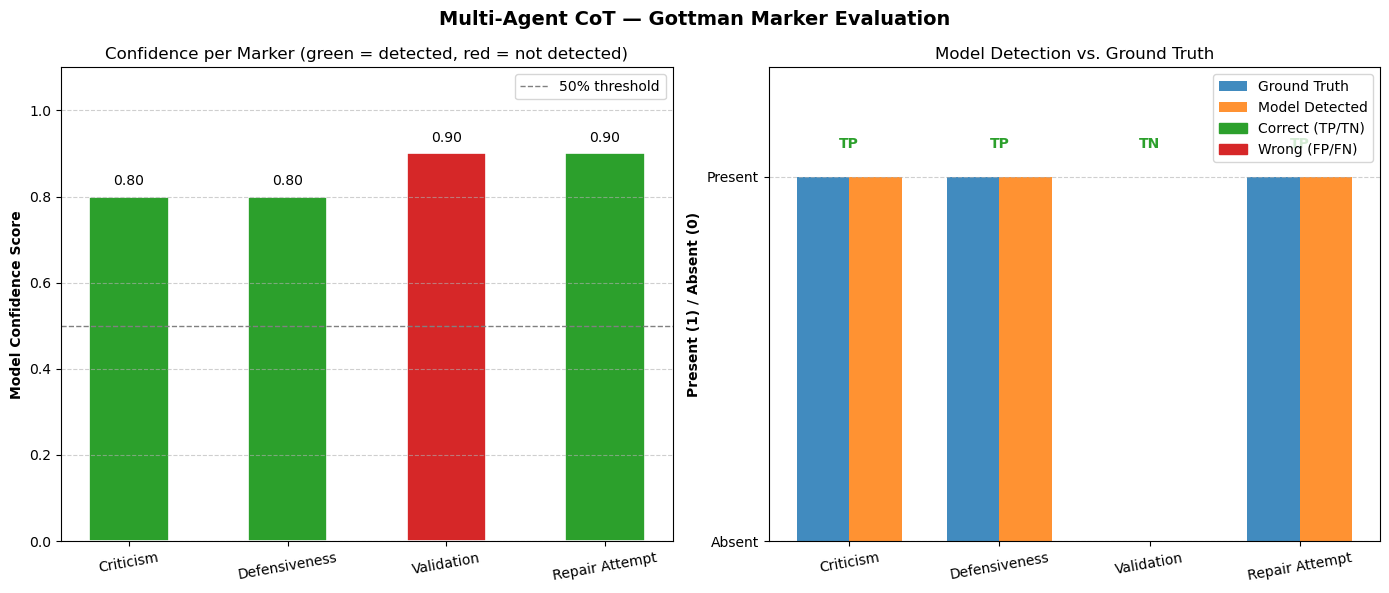

💾 Saved → full_behavior_analysis_pipeline/model_performance.png


In [19]:
# ── visualize_results logic ───────────────────────────────────────────────────
# Adapted from visualize_results.py to work with single-session CoT output.
# The original script handles multi-item Obvious/Ambiguous buckets; this version
# renders per-marker confidence and a detected-vs-ground-truth comparison.

def generate_visualizations(results: list, output_path: str) -> None:
    markers = ["criticism", "defensiveness", "validation", "repair_attempt"]
    marker_labels = [m.replace("_", " ").title() for m in markers]

    # Collect per-marker stats across all items
    confidence_scores = {m: [] for m in markers}
    tp = {m: 0 for m in markers}
    fp = {m: 0 for m in markers}
    tn = {m: 0 for m in markers}
    fn = {m: 0 for m in markers}

    for item in results:
        ground_truth = item.get("ground_truth", {})
        model_analysis = item.get("model_analysis", {})

        for m in markers:
            gt_val = bool(ground_truth.get(m, False))
            model_val = bool(model_analysis.get(m, {}).get("detected", False))
            conf = float(model_analysis.get(m, {}).get("confidence", 0.0))
            confidence_scores[m].append(conf)

            if gt_val and model_val:
                tp[m] += 1
            elif not gt_val and model_val:
                fp[m] += 1
            elif not gt_val and not model_val:
                tn[m] += 1
            elif gt_val and not model_val:
                fn[m] += 1

    avg_confidence = [
        np.mean(confidence_scores[m]) if confidence_scores[m] else 0.0
        for m in markers
    ]
    ground_truth_vals = [
        bool(results[0]["ground_truth"].get(m, False)) for m in markers
    ]
    detected_vals = [
        bool(results[0]["model_analysis"].get(m, {}).get("detected", False))
        for m in markers
    ]

    x = np.arange(len(markers))
    width = 0.35

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(
        "Multi-Agent CoT — Gottman Marker Evaluation",
        fontsize=14, fontweight="bold"
    )

    # ── Left: Model confidence per marker ──────────────────────────────────
    colors = ["#2ca02c" if d else "#d62728" for d in detected_vals]
    bars = ax1.bar(x, avg_confidence, color=colors, width=0.5, edgecolor="white", linewidth=1.2)
    ax1.axhline(y=0.5, color="gray", linestyle="--", linewidth=1, label="50% threshold")
    ax1.set_ylabel("Model Confidence Score", fontweight="bold")
    ax1.set_title("Confidence per Marker (green = detected, red = not detected)")
    ax1.set_xticks(x)
    ax1.set_xticklabels(marker_labels, rotation=10)
    ax1.set_ylim(0, 1.1)
    ax1.grid(axis="y", linestyle="--", alpha=0.6)
    for bar, val in zip(bars, avg_confidence):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f"{val:.2f}", ha="center", va="bottom", fontsize=10)
    ax1.legend()

    # ── Right: Detected vs. Ground-Truth comparison ────────────────────────
    gt_numeric = [1 if v else 0 for v in ground_truth_vals]
    det_numeric = [1 if v else 0 for v in detected_vals]

    ax2.bar(x - width / 2, gt_numeric, width, label="Ground Truth",
            color="#1f77b4", alpha=0.85)
    ax2.bar(x + width / 2, det_numeric, width, label="Model Detected",
            color="#ff7f0e", alpha=0.85)

    # Outcome annotation
    outcome_colors = {"TP": "#2ca02c", "TN": "#2ca02c", "FP": "#d62728", "FN": "#d62728"}
    for i, m in enumerate(markers):
        if tp[m]:
            label = "TP"
        elif tn[m]:
            label = "TN"
        elif fp[m]:
            label = "FP"
        else:
            label = "FN"
        ax2.text(x[i], 1.08, label, ha="center", fontsize=10,
                 color=outcome_colors[label], fontweight="bold")

    ax2.set_ylabel("Present (1) / Absent (0)", fontweight="bold")
    ax2.set_title("Model Detection vs. Ground Truth")
    ax2.set_xticks(x)
    ax2.set_xticklabels(marker_labels, rotation=10)
    ax2.set_ylim(0, 1.3)
    ax2.set_yticks([0, 1])
    ax2.set_yticklabels(["Absent", "Present"])
    ax2.grid(axis="y", linestyle="--", alpha=0.6)
    ax2.legend()

    correct = mpatches.Patch(color="#2ca02c", label="Correct (TP/TN)")
    wrong = mpatches.Patch(color="#d62728", label="Wrong (FP/FN)")
    ax2.legend(handles=[*ax2.get_legend_handles_labels()[0], correct, wrong])

    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.show()
    print(f"💾 Saved → {output_path}")


generate_visualizations(analysis_results, VISUALIZATION_PATH)

---
## Step 5 — Generate Dynamic Clinical Report

**Source:** `generate_dynamic_report.py`

Uses the analysis JSON to build a structured telemetry log, then prompts the LLM to translate the raw signal data into a professional clinical narrative suitable for the couple.

Output is written to `full_behavior_analysis_pipeline/session_summary_report.txt`.

In [20]:
# ── generate_dynamic_report logic ────────────────────────────────────────────

def generate_dynamic_report(results: list, output_path: str) -> str:
    """
    Builds a telemetry log from the analysis JSON, prompts the LLM to write
    a clinical narrative, and saves both to disk.
    Mirrors generate_dynamic_report.py exactly.
    """
    client = Client()

    session = next((item for item in results if item["id"] == 101), results[0])
    analysis = session["model_analysis"]

    # Programmatically compile the raw telemetry block
    ugly_log = (
        "================================================================================\n"
        "                           !!! DEV_SESSION_LOG_DUMP !!!                         \n"
        "================================================================================\n"
        "SESSION LENGTH: 2:43\n"
        "--------------------------------------------------------------------------------\n"
    )

    if analysis["criticism"]["detected"]:
        ugly_log += f"00:31 Possible criticism — HIGH \"{analysis['criticism'].get('evidence', '')}\"\n"
    if analysis["defensiveness"]["detected"]:
        ugly_log += f"00:37 Possible defensiveness — MODERATE \"{analysis['defensiveness'].get('evidence', '')}\"\n"
    if analysis["repair_attempt"]["detected"]:
        ugly_log += f"01:12 Possible repair attempt — MODERATE \"{analysis['repair_attempt'].get('evidence', '')}\"\n"
    if analysis["validation"]["detected"]:
        ugly_log += f"01:16 Validation — HIGH \"{analysis['validation'].get('evidence', '')}\"\n"

    ugly_log += (
        "--------------------------------------------------------------------------------\n"
        "SUMMARY\n"
        f"Criticism {1 if analysis['criticism']['detected'] else 0}\n"
        f"Defensiveness {1 if analysis['defensiveness']['detected'] else 0}\n"
        f"Validation {1 if analysis['validation']['detected'] else 0}\n"
        f"Repair attempts {1 if analysis['repair_attempt']['detected'] else 0}\n"
        "================================================================================\n"
    )

    print("📝 Building raw terminal layout stream...")
    print(ugly_log)
    print("🤖 Prompting LLM to synthesize clinical translation narrative...")

    narrative_prompt = (
        "You are an expert relationship counselor. Review the following raw telemetry log data.\n"
        "Translate these technical metrics into a clear, professional narrative report for the couple.\n\n"
        "CRITICAL RULES:\n"
        "1. Start your response EXACTLY with the text: 'One pattern worth reviewing occurred around 00:31...'\n"
        "2. Do NOT mention code, JSON, Pydantic, data frames, or software parameters.\n"
        "3. Focus on the progression of the interaction: how criticism led to defensiveness, how the repair was attempted, and whether validation was achieved.\n\n"
        f"Telemetry Data to Translate:\n{ugly_log}"
    )

    response = client.chat(
        model="llama3.2",
        messages=[{"role": "user", "content": narrative_prompt}]
    )
    llm_narrative = response["message"]["content"]

    final_output = f"{ugly_log}\n\n--- CLINICAL TRANSLATION NARRATIVE ---\n\n{llm_narrative}\n"

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(final_output)

    return final_output


report_text = generate_dynamic_report(analysis_results, REPORT_PATH)
print(f"\n💾 Saved → {REPORT_PATH}")

📝 Building raw terminal layout stream...
                           !!! DEV_SESSION_LOG_DUMP !!!                         
SESSION LENGTH: 2:43
--------------------------------------------------------------------------------
00:31 Possible criticism — HIGH "These lines convey a sense of blame and accusation, implying that Speaker A is not confident in their partner's ability to manage their time."
00:37 Possible defensiveness — MODERATE "These lines convey a sense of defensiveness and accusation, implying that Speaker B is trying to protect themselves from criticism."
01:12 Possible repair attempt — MODERATE "These lines convey a genuine attempt to diffuse tension and repair the relationship, with Speaker B taking ownership of their emotional response and apologizing for their behavior."
--------------------------------------------------------------------------------
SUMMARY
Criticism 1
Defensiveness 1
Validation 0
Repair attempts 1

🤖 Prompting LLM to synthesize clinical translation na

---
## Final Output — Display Report

In [18]:
print("── Final Report ──────────────────────────────────────────────────────────")
print(report_text)

print("\n── Output files ──────────────────────────────────────────────────────────")
for path in [LIVE_SAMPLE_PATH, ANALYSIS_RESULTS_PATH, VISUALIZATION_PATH, REPORT_PATH]:
    size = os.path.getsize(path) if os.path.exists(path) else 0
    print(f"  {path}  ({size:,} bytes)")

── Final Report ──────────────────────────────────────────────────────────
                           !!! DEV_SESSION_LOG_DUMP !!!                         
SESSION LENGTH: 2:43
--------------------------------------------------------------------------------
00:31 Possible criticism — HIGH "These lines convey a sense of blame and accusation, implying that Speaker A is not confident in their partner's ability to manage their time."
00:37 Possible defensiveness — MODERATE "These lines convey a sense of defensiveness and accusation, implying that Speaker B is trying to protect themselves from criticism."
01:12 Possible repair attempt — MODERATE "These lines convey a genuine attempt to diffuse tension and repair the relationship, with Speaker B taking ownership of their emotional response and apologizing for their behavior."
--------------------------------------------------------------------------------
SUMMARY
Criticism 1
Defensiveness 1
Validation 0
Repair attempts 1


--- CLINICAL TRANS